In [373]:
from qat.fermion.hamiltonians import FermionHamiltonian, SpinHamiltonian
from qat.fermion.hamiltonians import make_anderson_model
from qat.fermion.trotterisation import make_trotterisation_routine
from qat.lang import *
from qat.core import Term, Schedule, Variable, Observable
from qat.qpus import get_default_qpu, ClassicalQPU, PyLinalg
from qat.plugins import ScipyMinimizePlugin
from scipy.optimize import minimize
from qat.lang.AQASM import Program, QRoutine

import numpy as np

import matplotlib.pyplot as plt
from collections import deque

from scipy.optimize import minimize
from scipy.linalg import expm

On commence d'abord par définir l'opérateur $c^{\dagger}_{i, \sigma1}c_{j, \sigma2}$ qui va être utilisé pour définir le hamiltonien :

In [374]:
#Definition de l'operateur  
def couplingOp(n_qubits: int, energy: float, i: int, j: int, spin_i: str, spin_j: str) : 
    """ Calcule une instance de FermionHamiltonian associée à l'opérateur c^{dagger}_{i, sigma1}c_{j, sigma2}, 
    i et j sont les numéros de site, energy est le préfacteur énergétique apparaissant dans 
    la définition du hamiltonien. """
    if spin_i == "+" :
         if spin_j == "-" :
            return FermionHamiltonian(n_qubits, [Term(energy, "Cc", [i, j+1])])
         else :
            return FermionHamiltonian(n_qubits, [Term(energy, "Cc", [i, j])])
    else :
         if spin_j == "-" :
            return FermionHamiltonian(n_qubits, [Term(energy, "Cc", [i+1, j+1])])
         else :
            return FermionHamiltonian(n_qubits, [Term(energy, "Cc", [i+1, j])]) 
        
def nOp(n_qubits, energy, i, spin) :
    """Calcule une instance de FermionHamiltonian associée à l'opérateur n_{i, spin} avec le préfacteur energy."""
    return couplingOp(n_qubits, energy, i, i, spin, spin)
    

In [375]:
print(couplingOp(4,2,1,2,"+","-"))
print((couplingOp(4,1,0,0,"-","-")))


2 * (Cc|[1, 3])
1 * (Cc|[1, 1])


Definition de l'Hamiltonien de Anderson (avec la possibilité de choisir le nombre d'impuretés contrairement à la fonction make_anderson_model de myQLM)

In [376]:
#Definition de l'hamiltonien
def hamiltonian(n_impurities: int, n_bain: int, U: float, mu: float, t: float, V, epsilon: list) :
    """ Calcule le hamiltonien du modèle d'Anderson et le renvoie sous la forme 
    du couple (SpinHamiltonian, matrice associée)."""
    n_qubits = 2 * n_bain + 2 * n_impurities
    H_repulsion = 0
    H_hopping = 0
    H_chem = 0
    for wire in range(0, 2*n_impurities, 2) :
        #Calcul du terme de potentiel chimique
        H_chem += nOp(n_qubits, -mu, wire, "+")
        H_chem += nOp(n_qubits, -mu, wire, "-")

        #Calcul du terme d'effet tunnel entre impuretés, dit "hopping"
        for wire2 in range(0, 2*n_impurities, 2) :
            if wire2 != wire :
                H_hopping += couplingOp(n_qubits, -t, wire, wire2, "+", "-")
                H_hopping += couplingOp(n_qubits, -t, wire, wire2, "+", "+")
                H_hopping += couplingOp(n_qubits, -t, wire, wire2, "-", "-")
                H_hopping += couplingOp(n_qubits, -t, wire, wire2, "-", "+")
            else :
                #Calcul du terme de répulsion coulombienne
                H_repulsion += nOp(n_qubits, U, wire, "+")*nOp(n_qubits, 1, wire,"-")
    
    H_impurity_bath = 0
    H_bath = 0
    for wire3 in range(2*n_impurities, n_qubits, 2) :
        i = (wire3 - 2*n_impurities) // 2
        e = epsilon[i]
        #Calcul du terme lié au bain
        H_bath += nOp(n_qubits, e, wire3, "+")
        H_bath += nOp(n_qubits, e, wire3, "-")
        
        for wire4 in range(0, 2*n_impurities, 2) :
            #Calcul du terme d'interaction impureté-bain
            j = wire4 // 2
            v = V[j][i]
            vstar = v if np.isreal(v) else np.conj(v)
            
            H_impurity_bath += couplingOp(n_qubits, v, wire4, wire3, "+", "+") 
            H_impurity_bath += couplingOp(n_qubits, vstar, wire3, wire4, "+", "+")
            
            H_impurity_bath += couplingOp(n_qubits, v, wire4, wire3, "-", "-") 
            H_impurity_bath += couplingOp(n_qubits, vstar, wire3, wire4, "-", "-")
        

    H_anderson = H_repulsion + H_chem + H_impurity_bath + H_bath + H_hopping
    H_spin = H_anderson.to_spin(method = "jordan-wigner")#Fermion to Qubit
    return H_spin, H_spin.get_matrix()


In [377]:
H_test= SpinHamiltonian(1, [Term(1/np.sqrt(2), "Z", [0]), Term(1/np.sqrt(2), "X", [0])])
print(H_test)


0.7071067811865475 * (Z|[0]) +
0.7071067811865475 * (X|[0])


In [378]:

H_1 = SpinHamiltonian(4, [Term(-1, "ZZ", [0,1]), Term(-1, "ZZ", [1,2]), 
                                     Term(-1, "ZZ", [2,3]), Term(-1, "ZZ", [0,3])])

AndersonHamiltonian, matrix = hamiltonian(1, 1, 1, 1, 0, [[1]], [1]) 
print(np.linalg.eigvals(matrix))

[-2.17740968e+00+0.j  3.21637174e-01+0.j  2.85577251e+00+0.j
  1.41421356e+00+0.j -1.41421356e+00+0.j  1.41421356e+00+0.j
 -1.41421356e+00+0.j -6.18033989e-01+0.j  3.14010730e-17+0.j
  1.61803399e+00+0.j -6.18033989e-01+0.j  1.61803399e+00+0.j
  0.00000000e+00+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j
  1.00000000e+00+0.j]


In [379]:
H_0, matrixH_0 = hamiltonian(1, 1, 1, 1, 0, [[0]], [1])
AndersonHamiltonian, matrix = hamiltonian(1, 1, 1, 1, 0, [[2]], [4]) 


<h3>Implementation du HVA pour passer d'un hamiltonien connu (diagonalisable) à notre hamiltonien d'Anderson</h3>

[3.0813382560832454, 4.67211555195191, 3.0813382560832436, -1.6368354221412096, -1.6368354221412087, 0.8130630269820021, -1.6368354221412087, 0.8576728672165537, -0.022062688923767837, 4.4740066823755456, -1.6368354221412051, 0.4875092013502602, -1.636835422141215, 0.6928380064585027, 0.3290460905527226, -1.3781319017852969, -0.5775234795688737, -1.6368354221412176, -1.6625501813575125, -1.017914375549684, -1.3750426597351941, -1.3738381368927266, 0.7124744752797394, -1.1497230638134468, -1.6625501813575116, -1.358772293733499, -1.6625501813575143, -0.9776794224934395, -1.6884563415290543, -1.5366138863997758, -1.6802550968668246, -1.310294163805768, -0.9578066408254999, -1.5812144128306418, -1.69791811958115, -1.3788641490214157, -1.690837053244179, -1.6990485985386208, -1.6029646437831122, -1.6990485985386377, -1.6703563777404318, -1.6998005656851616, -1.6942494773657302, -1.6252937064938582, -1.678450664541094, -1.6992906519564324, -1.6873179103681029, -1.6989552280346123, -1.678297

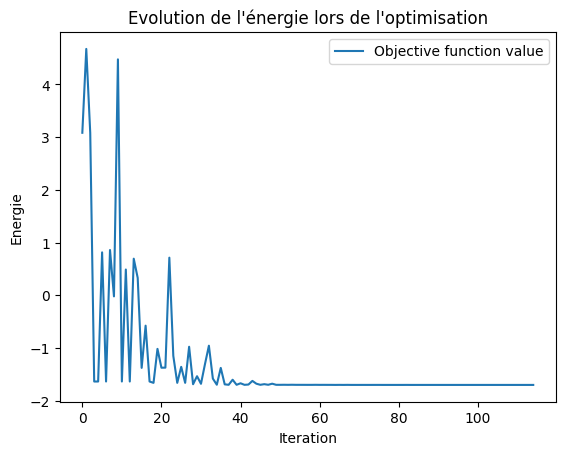

énergie avant optimisation 3.081338256083245
l'énergie du fondamental : -1.7015613308122521
paramètres : [ 0.55061545  0.97472275  2.174505    1.22623832 -0.28589294  0.40613503
 -0.04484791  0.22616293]


In [380]:
def hva_ansatz(psi_0, depth, hamiltonians,
                h_target, n_steps,  params) : #prend des hamiltoniens de spin et simule un recuit quantique
    k = len(hamiltonians)
    n = h_target.nbqbits
    rout = QRoutine()
    rout.apply(psi_0, [range(n)])
    for i in range(depth) :
        for j in range(k) :
            routTarget = make_trotterisation_routine(h_target, 
                                                n_trotter_steps = n_steps, 
                                                final_time = params[(k+1)*i + k])
            rout.apply(routTarget, [range(n)])
            rout1 = make_trotterisation_routine(hamiltonians[j], 
                                                 n_trotter_steps=n_steps,
                                                final_time= params[(k+1)*i + j])
            rout.apply(rout1, [range(n)])
            
    return rout

def cost_function(psi0, depth, hamiltonians,
                h_target, n_steps,  params) :
    
    job = hva_ansatz(psi0, depth, hamiltonians,
                h_target, n_steps,  params).to_job(observable = h_target)
    qpu = get_default_qpu()
    result = qpu.submit(job)
    return result.value

initial_state = QRoutine()
initial_state.apply(I, 0)
initial_state.apply(Y.dag(), 1)
initial_state.apply(X, 1)
initial_state.apply(Y, 2)
initial_state.apply(I, 3)


initial_params = [0.9, 0.01, 2, 0.2, 0.1, 0.5]
randomInitial_params = np.random.random(8)
variational_circuit = lambda params: cost_function(initial_state, 4, [H_1], AndersonHamiltonian, 1, params)
function_values = []

def callback(params) :
    function_values.append(variational_circuit(params))

ground_state_energy = minimize(variational_circuit, x0 = randomInitial_params, method='COBYLA', callback=callback)
print(function_values)
# Plot the evolution of the function values
plt.plot(function_values, label='Objective function value')
plt.xlabel('Iteration')
plt.ylabel('Energie')
plt.title("Evolution de l'énergie lors de l'optimisation")
plt.legend()
plt.show()
print("énergie avant optimisation", variational_circuit(randomInitial_params))
print("l'énergie du fondamental :", ground_state_energy.fun)
print("paramètres :", ground_state_energy.x)

psi0 = hva_ansatz(initial_state, 4, [H_1], AndersonHamiltonian, 1, ground_state_energy.x)


In [381]:
psi0.display()
job = psi0.to_job()

resultat = get_default_qpu().submit(job)

print("|Psi>")
psi0_dict = {}
for sample in resultat :
    psi0_dict[sample.state.bitstring] = sample.amplitude

print(psi0_dict)

|Psi>
{'0010': (0.2893700445994568+0.16139568737427792j), '1000': (-0.8240649758948396-0.45949246445281794j)}


<h2>Ça marche !!!</h2> (à tester toutefois avec un vrai état fondamental en entrée)

Il faut aussi prendre en compte les termes d'annihilation et de création, puisqu'ils ne sont pas unitaires, on les décompose comme sommes d'unitaire avec la transformation de Jordan-Wigner, on a : 
$$
c_{i,\uparrow} = \frac{1}{2} \left(X_{2i} + i Y_{2i} \right) \prod_{j<2i} Z_j
$$
$$
c_{i,\downarrow} = \frac{1}{2} \left(X_{2i+1} + i Y_{2i+1} \right) \prod_{j<2i+1} Z_j
$$
$$
c_{i,\uparrow}^{\dagger} = \frac{1}{2} \left(X_{2i} - i Y_{2i} \right) \prod_{j<2i} Z_j
$$
$$
c_{i,\downarrow}^{\dagger} = \frac{1}{2} \left(X_{2i+1} - i Y_{2i+1} \right) \prod_{j<2i+1} Z_j
$$

On a aussi $iY = RY(-\pi) = \begin{pmatrix}
0 & 1 \\
-1 & 0
\end{pmatrix}
$ and $-iY = RY(\pi)$

Maintenant on code un circuit correspondant à $c_{j,\sigma}(t)$ and $c_{i, \sigma'}^{\dagger}(0)$ 

In [382]:
def cMapping(index, spin) : 
    '''index commence à 0, repésente soit une impureté (0 <= index<= nb impuretés - 1) soit un mode de bain 5(nb impuretés <= index<= nb qubits - 1'''
    routX = QRoutine()
    routY = QRoutine()
    qubitsActedOn_X = []
    qubitsActedOn_Y = []
    if spin == "+" :
        routX.apply(X, 2*index)
        routY.apply(RY(-np.pi), 2*index) #+iY
        
        for wire in range(2 * index) : 
            routX.apply(Z, wire)
            qubitsActedOn_X.append(wire)
            routY.apply(Z, wire)
            qubitsActedOn_Y.append(wire)

        qubitsActedOn_X.append(2*index)
        qubitsActedOn_Y.append(2*index)

    else : #spin down
        routX.apply(X, 2*index + 1)
        routY.apply(RY(-np.pi), 2*index + 1)
        for wire in range(2 * index + 1) :
            routX.apply(Z, wire)
            qubitsActedOn_X.append(wire)
            routY.apply(Z, wire)
            qubitsActedOn_Y.append(wire)

        qubitsActedOn_X.append(2*index + 1)
        qubitsActedOn_Y.append(2*index + 1)
            
    return routX, qubitsActedOn_X, routY, qubitsActedOn_Y
    

In [383]:
def cDagMapping(index, spin) :
    '''index commence à 0, repésente soit une impureté (0 <= index<= nb impuretés - 1) soit un mode de bain 5(nb impuretés <= index<= nb qubits - 1'''
    routX = QRoutine()
    routY = QRoutine()
    qubitsActedOn_X = []
    qubitsActedOn_Y = []
    if spin == "+" :
        routX.apply(X, 2*index)
        routY.apply(RY(np.pi), 2*index) #+iY
        
        for wire in range(2 * index) : 
            routX.apply(Z, wire)
            qubitsActedOn_X.append(wire)
            routY.apply(Z, wire)
            qubitsActedOn_Y.append(wire)

        qubitsActedOn_X.append(2*index)
        qubitsActedOn_Y.append(2*index)

    else : #spin down
        routX.apply(X, 2*index + 1)
        routY.apply(RY(-np.pi), 2*index + 1)
        for wire in range(2 * index + 1) :
            routX.apply(Z, wire)
            qubitsActedOn_X.append(wire)
            routY.apply(Z, wire)
            qubitsActedOn_Y.append(wire)

        qubitsActedOn_X.append(2*index + 1)
        qubitsActedOn_Y.append(2*index + 1)
            
    return routX, qubitsActedOn_X, routY, qubitsActedOn_Y

routX, qubitsActedOn_X, routY, qubitsActedOn_Y = cDagMapping(1, "-")
routX.display()
routY.display()


In [384]:
routX, a, routY, b = cMapping(0, "-")
routX_dag, j, routY_dag, j1 = cDagMapping(0,"+")
routX.display()
routY.display()


XYarray (2 element array) ci-dessous se réfère à ce que nous calculons, soit la chaîne de Pauli qui comporte un X ou celle qui comporte un Y pour $c_i$, et la chaîne de Pauli qui comporte un X ou celle qui comporte un Y pour $c_j^{\dagger}$ pour le calcul des matrices unitaires dont la somme nous donne la fonction de Green. Par exemple, si XYarray = ["X", "Y"], nous calculons $e^{i H t} (X_{2i} \prod_{j<2i} Z_j) e^{- i H t}(-iY_{2i} \prod_{j<2i} Z_j)$ (si les deux spins sont vers le haut).

In [385]:
def circuitGreen(i, sigma_i, j, sigma_j, h, t, N, XYarray) :
    n = h.nbqbits
    rout = QRoutine()
    routX_c, qubitsX, routY_c, qubitsY = cMapping(i, sigma_i)
    routX_cdag, qubitsX_dag, routY_cdag, qubitsY_dag = cDagMapping(j, sigma_j)
    if XYarray[1] == "X" : #optimisation future circuitX_cdag = circuitX_c
        rout.apply(routX_cdag, qubitsX_dag)
    else :
        rout.apply(routY_cdag, qubitsY_dag)
    
    rout.apply(make_trotterisation_routine(h, n_trotter_steps=N, final_time=t), [range(n)]) #Trotterization avec -H

    if XYarray[0] == "X" :
        rout.apply(routX_c, qubitsX)
    else :
        rout.apply(routY_c, qubitsY)

    rout.apply(make_trotterisation_routine((-1)*h, n_trotter_steps=N, final_time=t), [range(n)]) #Trotterization avec H

    return rout

In [386]:
Hx = SpinHamiltonian(1, [Term(1, "X", [0])])

In [387]:
circuitGreen(0, "+", 0, "+", Hx, t=3, N=1, XYarray=["X","X"]).display()

In [388]:
def circuitGreenProba(i, sigma_i, j, sigma_j, h, t, N, XYarray) :
    proba = {}
    job = circuitGreen(i, sigma_i, j, sigma_j, h, t, N, XYarray).to_job()
    qpu = get_default_qpu()
    result = qpu.submit(job)

    for sample in result :
        proba[sample.state.bitstring] = sample.probability
    
    return proba

circuitGreenProba(0, "+", 0, "+", AndersonHamiltonian, 1, 1, ["X", "X"])


{'0000': 0.17317818956819336, '1010': 0.8268218104318028}

Calcul de l'opérateur de corrélation pour $H_{test} = H$ pour des temps $t \in [0, 10]$

In [389]:
sigmaX = np.array([
        [0, 1],
        [1, 0]
    ])
ket1 = np.array([
    [0], 
    [1]
    ])

def calculThéorique(t) :
    expiHt = np.array([
        [np.cos(t) + 1j * np.sin(t)/np.sqrt(2) ,        1j*np.sin(t)/np.sqrt(2)     ],
        [1j * np.sin(t)/np.sqrt(2)             , np.cos(t) - 1j*np.sin(t)/np.sqrt(2)]
    ])
    exp_iHt = np.conj(expiHt)
    
    return np.absolute((expiHt @ sigmaX @ exp_iHt @ ket1)[0])**2

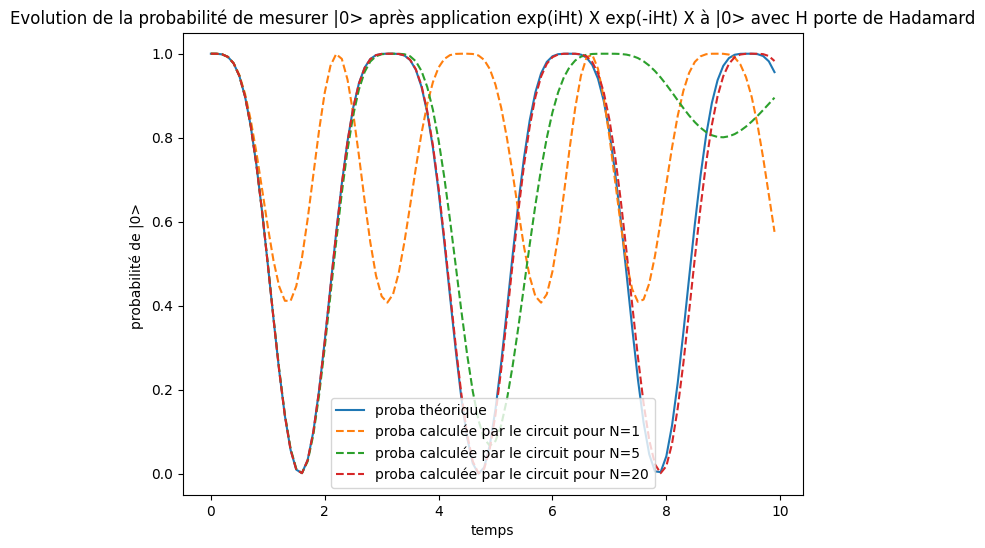

In [390]:
T = np.arange(0, 10, 0.1)
resultatTheorique = [calculThéorique(t) for t in T]
plt.figure(figsize=(8,6))
plt.plot(T, resultatTheorique, label = 'proba théorique')

for N_steps in [1, 5, 20] :
    resultatCirc = [circuitGreenProba(0, "+", 0, "+", H_test, t, N=N_steps, XYarray=["X","X"])["0"] for t in T]
    plt.plot(T, resultatCirc, label = f'proba calculée par le circuit pour N={N_steps}', linestyle='--')

plt.xlabel('temps')
plt.ylabel('probabilité de |0> ')
plt.title("Evolution de la probabilité de mesurer |0> après application exp(iHt) X exp(-iHt) X à |0> avec H porte de Hadamard")
plt.legend()
plt.show()
    


Calcul de l'opérateur de corrélation pour $H_{test2} = \begin{pmatrix} 5 & 2 - 3i \\ 2 + 3i & -3 \end{pmatrix}
$ pour des temps $t \in [0, 1000]$


In [391]:
H_test2= SpinHamiltonian(1, [Term(1, "I", [0]), Term(2, "X", [0]),
                             Term(3, "Y", [0]), Term(4, "Z", [0])])
print(H_test2)


1.0 * I^1 +
2 * (X|[0]) +
3 * (Y|[0]) +
4 * (Z|[0])


In [392]:
def calculThéorique2(t) :
    iHt = 1j * t * np.array([
        [   5   , 2 - 3j ],
        [2 + 3j ,   -3   ]
        ])
    expiHt = expm(iHt)
    exp_iHt = expm(- iHt)
    return np.absolute((expiHt @ sigmaX @ exp_iHt @ ket1)[0])**2


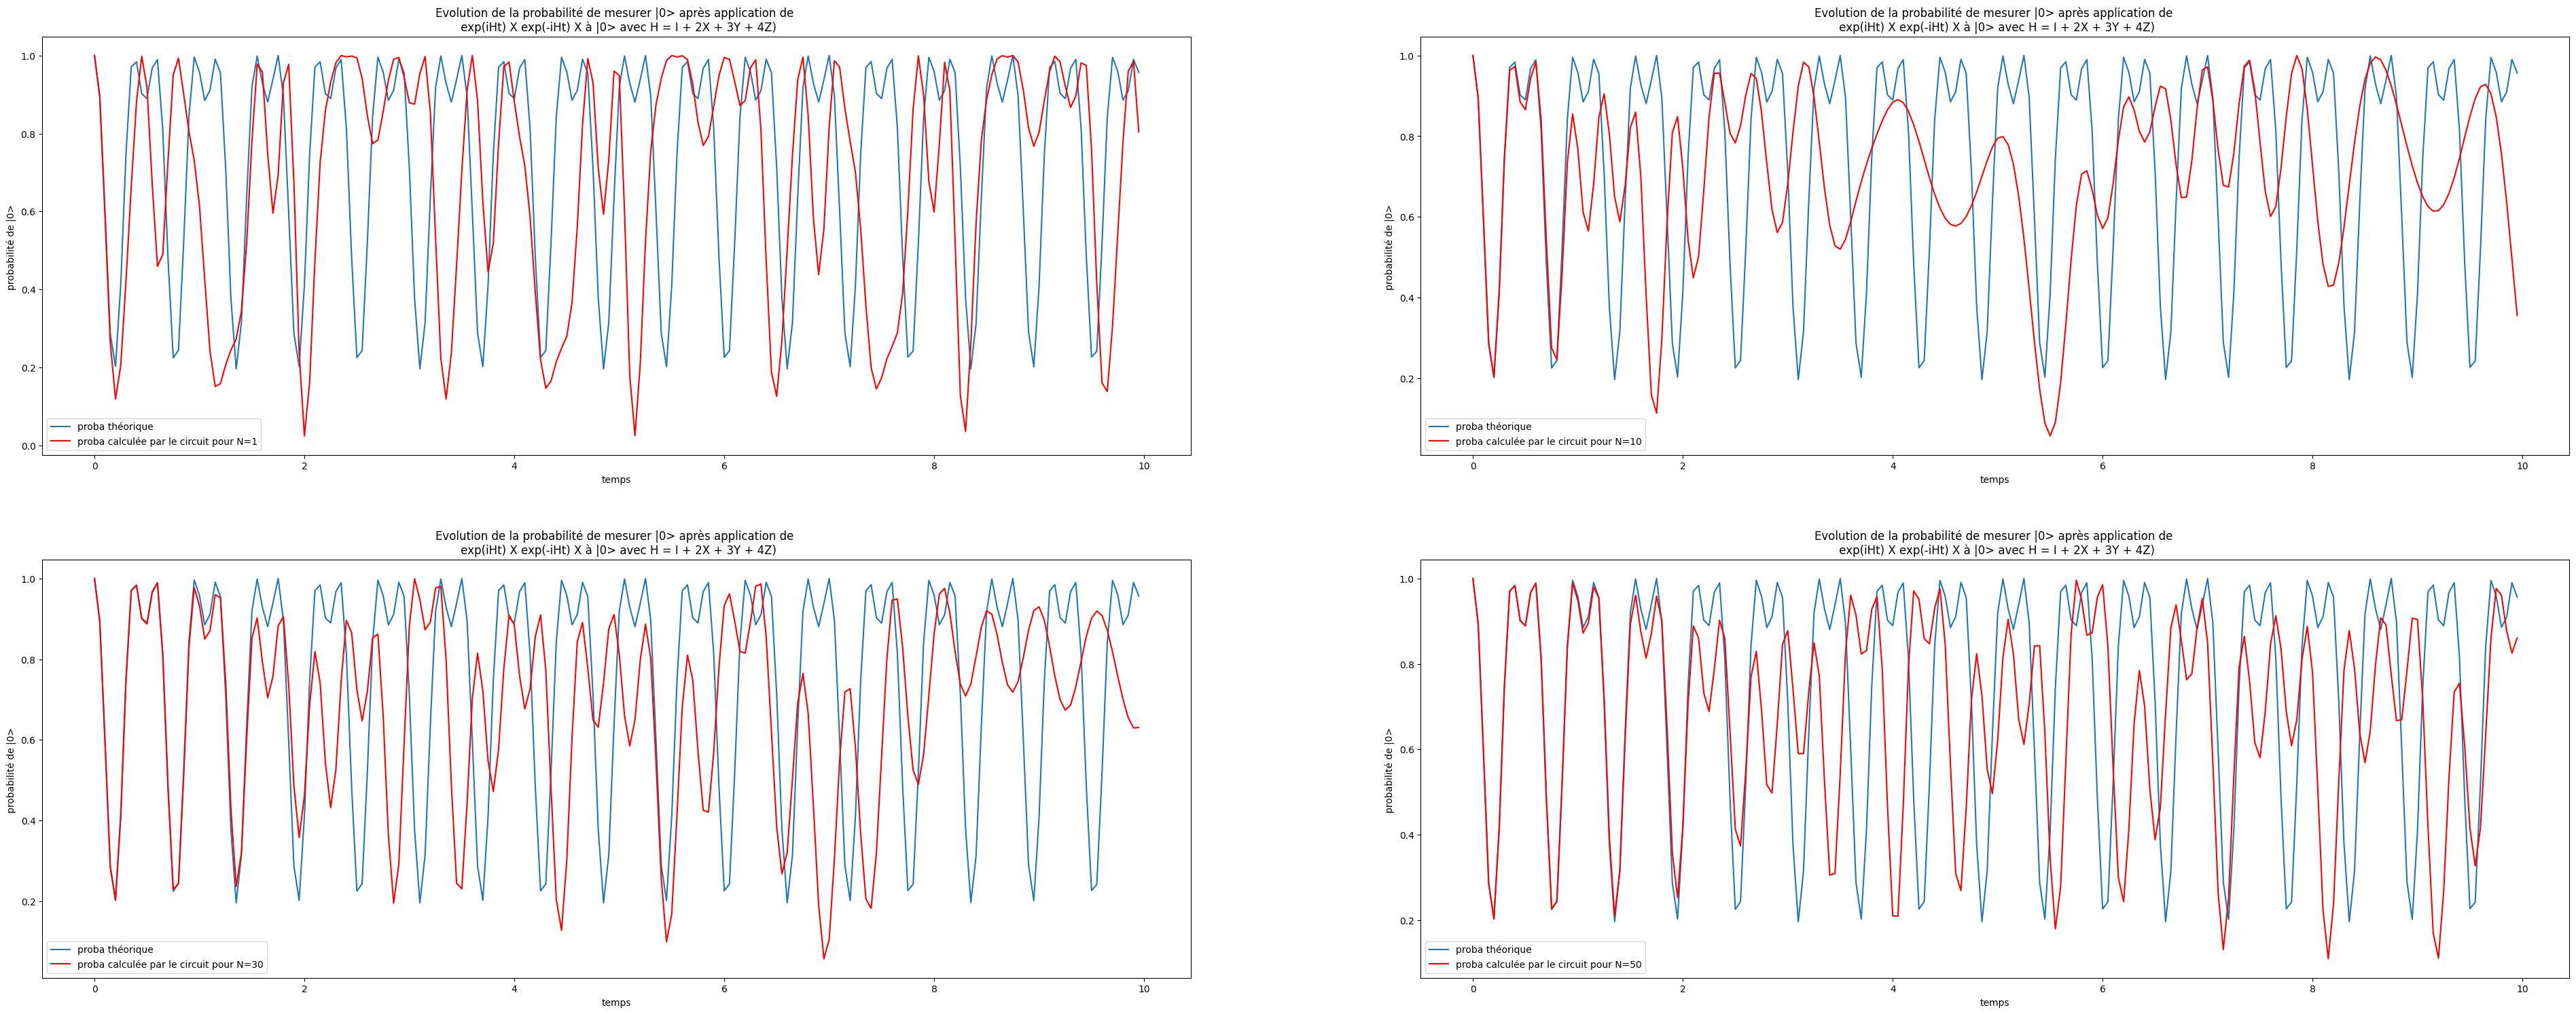

In [393]:
T = np.arange(0, 10, 0.05)
resultatTheorique = np.ravel(np.array([calculThéorique2(t) for t in T]))
fig2, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(48, 18))

for ax, n_steps in [(ax1, 1), (ax2, 10), (ax3, 30), (ax4, 50)] :
    ax.plot(T, resultatTheorique, label = 'proba théorique')
    resultatCirc = np.array([circuitGreenProba(0, "+", 0, "+", H_test2, t, N=n_steps, XYarray=["X","X"])["0"] for t in T])
    ax.plot(T, resultatCirc, label = f'proba calculée par le circuit pour N={n_steps}', color="r" )

    ax.set_xlabel('temps')
    ax.set_ylabel('probabilité de |0> ')
    ax.set_title("Evolution de la probabilité de mesurer |0> après application de \n exp(iHt) X exp(-iHt) X à |0> avec H = I + 2X + 3Y + 4Z)")
    ax.legend()

plt.subplots_adjust(hspace=0.25)
plt.show()
    

Calcul de l'opérateur de corrélation pour $H_{test3} = \begin{pmatrix} cos(\theta) & -i sin(\theta) \\ i sin(\theta) & cos(\theta) \end{pmatrix}
$ pour des temps $t \in [0, 100]$


In [394]:
def H_test3(theta) :
    return SpinHamiltonian(1, [Term(np.cos(theta), "I", [0]), Term(np.sin(theta), "Y", [0])])

print(H_test3(np.pi / 3))

0.5000000000000001 * I^1 +
0.8660254037844386 * (Y|[0])


In [395]:
def calculThéorique3(t, theta) :
    iHt = 1j * t * np.array([
        [np.cos(theta), -1j * np.sin(theta)], 
        [1j * np.sin(theta), np.cos(theta)]])
    expiHt = expm(iHt)
    exp_iHt = expm(- iHt)
    return np.absolute((expiHt @ sigmaX @ exp_iHt @ ket1)[0])**2


In [396]:
angle = { np.pi/3 : "π/3", np.pi/4 : "π/4", np.pi/6 : "π/6", np.pi/12 : "π/12"}

différence maximale : 2.8310687127941492e-14
différence maximale : 2.708944180085382e-14
différence maximale : 2.886579864025407e-14
différence maximale : 1.8096635301390052e-14
différence maximale : 1.9012569296705806e-14
différence maximale : 2.0761170560490427e-14
différence maximale : 2.6978419498391304e-14
différence maximale : 3.108624468950438e-14
différence maximale : 3.3084646133829665e-14
différence maximale : 2.220446049250313e-14
différence maximale : 2.1538326677728037e-14
différence maximale : 2.0317081350640365e-14


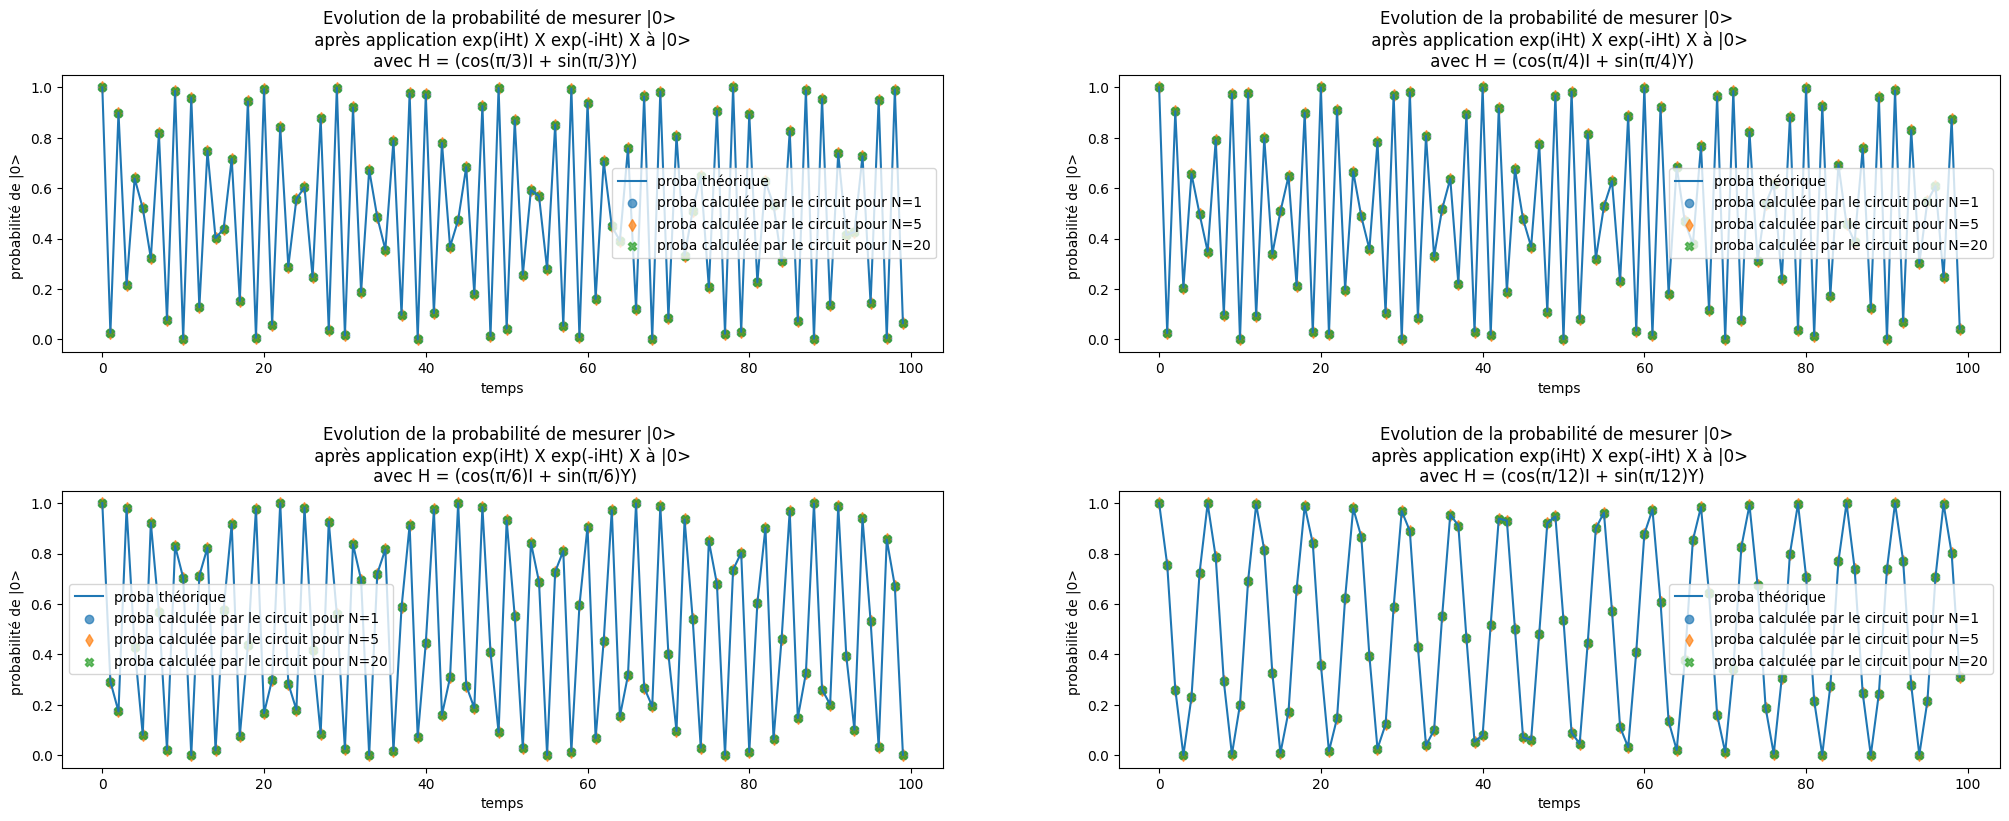

In [397]:
T = np.arange(0, 100, 1)


fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(25, 9))

for ax, theta in [(ax1, np.pi/3), (ax2, np.pi/4), (ax3, np.pi/6), (ax4, np.pi/12)] :
    resultatTheorique = np.ravel(np.array([calculThéorique3(t, theta) for t in T]))
    ax.plot(T, resultatTheorique, label = 'proba théorique')
    for n_steps, style in [(1, "o"), (5, 'd'), (20, 'X')] :
        
        resultatCirc = np.array([circuitGreenProba(0, "+", 0, "+", H_test3(theta), t, N=n_steps, XYarray=["X","X"])["0"] for t in T])
        print("différence maximale :", np.max(np.abs(resultatCirc - resultatTheorique)))
        ax.scatter(T, resultatCirc, alpha = 0.7, label = f'proba calculée par le circuit pour N={n_steps}', marker=style)
        ax.set_xlabel('temps')
        ax.set_ylabel('probabilité de |0> ')
        ax.set_title(f"Evolution de la probabilité de mesurer |0> \n après application exp(iHt) X exp(-iHt) X à |0> \n avec H = (cos({angle[theta]})I + sin({angle[theta]})Y)")
        ax.legend()

plt.subplots_adjust(hspace=0.5)
plt.show()

concordance quasi-parfaite mais résultat pas étonnant car I et Y commutent donc la trotterization est une égalité

Calcul de l'opérateur de corrélation pour $H_{test4} = \begin{pmatrix} cos(\theta) & sin(\theta) \\ sin(\theta) & cos(\theta) \end{pmatrix}
$ pour des temps $t \in [0, 100]$


In [398]:
def H_test4(theta) :
    return SpinHamiltonian(1, [Term(np.cos(theta), "I", [0]), Term(np.sin(theta), "X", [0])])

print(H_test4(np.pi / 3))

0.5000000000000001 * I^1 +
0.8660254037844386 * (X|[0])


In [399]:
def calculThéorique4(t, theta) :
    iHt = 1j * t * np.array([
        [np.cos(theta), np.sin(theta)], 
        [ np.sin(theta), np.cos(theta)]])
    expiHt = expm(iHt)
    exp_iHt = expm(- iHt)
    return np.absolute((expiHt @ sigmaX @ exp_iHt @ ket1)[0])**2


différence maximale : 3.597122599785507e-14
différence maximale : 5.218048215738236e-14
différence maximale : 2.19824158875781e-14
différence maximale : 3.4638958368304884e-14
différence maximale : 3.730349362740526e-14
différence maximale : 3.7969627442180354e-14
différence maximale : 2.6201263381153694e-14
différence maximale : 3.752553823233029e-14


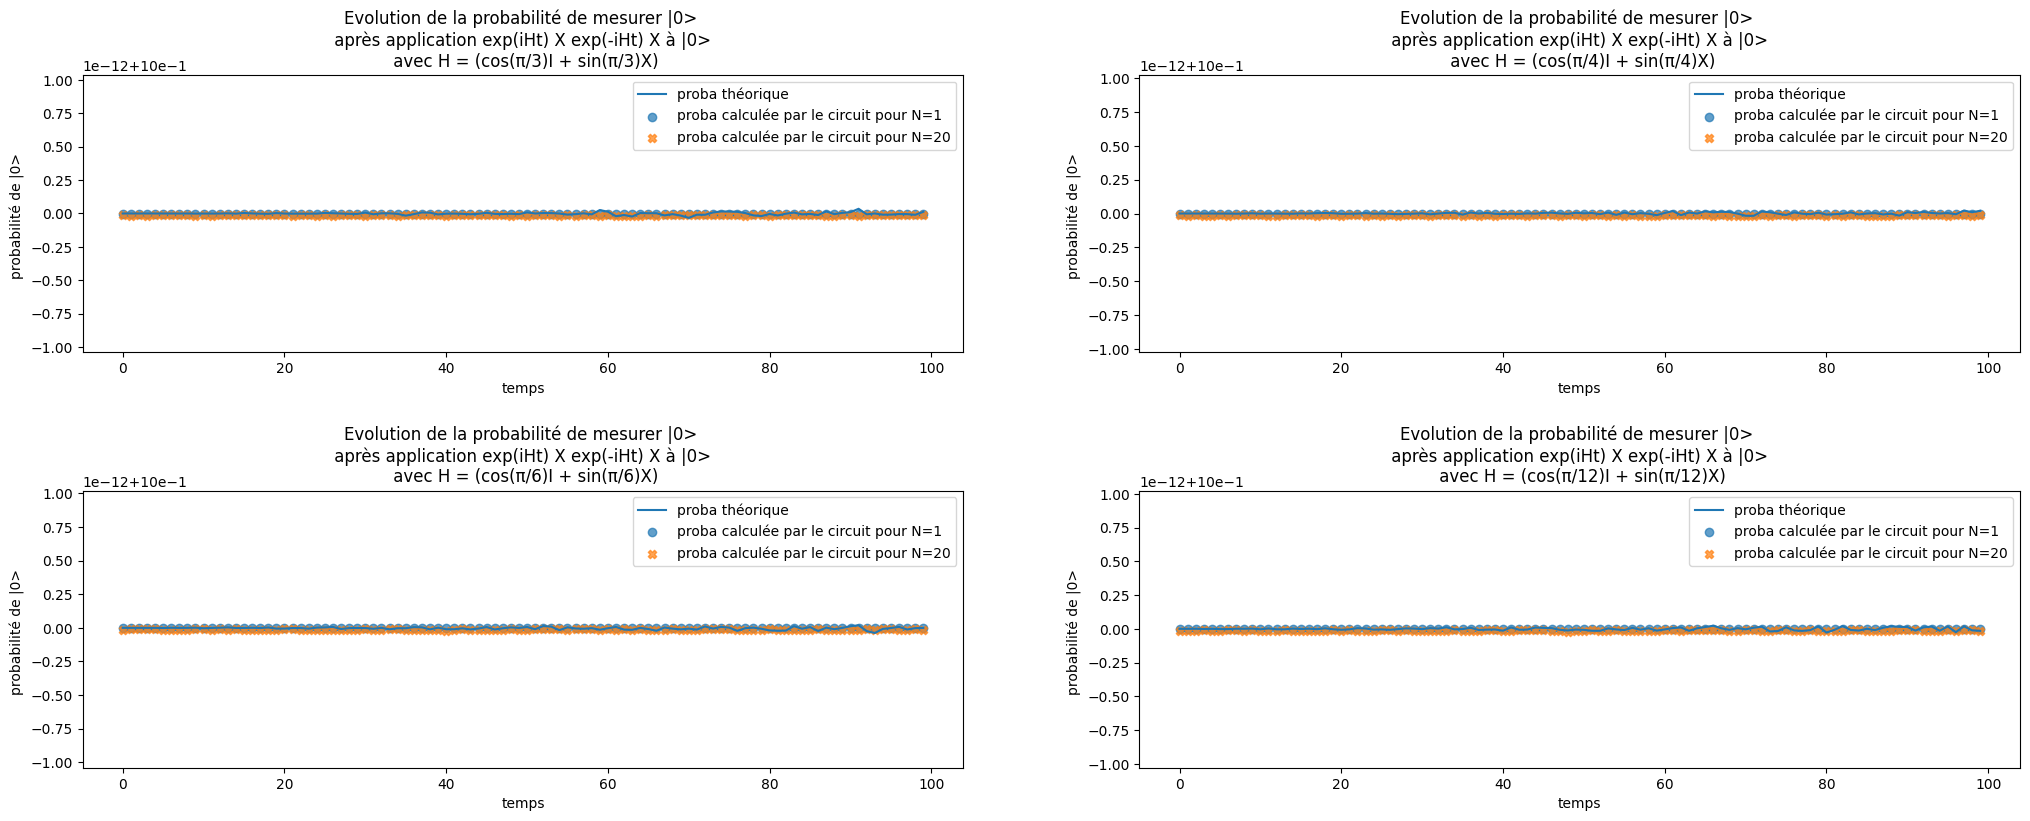

In [400]:
T = np.arange(0, 100, 1)


fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(25, 9))

for ax, theta in [(ax1, np.pi/3), (ax2, np.pi/4), (ax3, np.pi/6), (ax4, np.pi/12)] :
    resultatTheorique = np.ravel(np.array([calculThéorique4(t, theta) for t in T]))
    ax.plot(T, resultatTheorique, label = 'proba théorique')
    for n_steps, style in [(1, "o"), (20, 'X')] :
        
        resultatCirc = np.array([circuitGreenProba(0, "+", 0, "+", H_test4(theta), t, N=n_steps, XYarray=["X","X"])["0"] for t in T])
        print("différence maximale :", np.max(np.abs(resultatCirc - resultatTheorique)))
        ax.scatter(T, resultatCirc, alpha = 0.7, label = f'proba calculée par le circuit pour N={n_steps}', marker=style)
        ax.set_xlabel('temps')
        ax.set_ylabel('probabilité de |0> ')
        ax.set_title(f"Evolution de la probabilité de mesurer |0> \n après application exp(iHt) X exp(-iHt) X à |0> \n avec H = (cos({angle[theta]})I + sin({angle[theta]})X)")
        ax.legend()

plt.subplots_adjust(hspace=0.5)
plt.show()

In [401]:
AndersonHamiltonian, matrix = hamiltonian(1, 1, 1, 1, 0, [[1]], [1])

In [402]:

ket_0 = np.zeros((16,1))
ket_0[0] = 1

otherQubits = np.eye(8)
def calculTheoriqueAnderson(t, state) :
    I = np.eye(2)
    sigmaXIII = np.kron(np.kron(np.kron(sigmaX, I), I), I)
    iHt = 1j * t * matrix
    expiHt = expm(iHt)
    exp_iHt = expm(-iHt)
    ket_1 = sigmaXIII @ ket_0
    
    return np.absolute((expiHt @ sigmaXIII @ exp_iHt @ ket_1)[state])**2

for state in range(16) :
    print(calculTheoriqueAnderson(1, state))

[0.51215922]
[0.]
[0.]
[0.]
[0.]
[0.]
[0.]
[0.]
[0.]
[0.]
[0.48784078]
[0.]
[0.]
[0.]
[0.]
[0.]


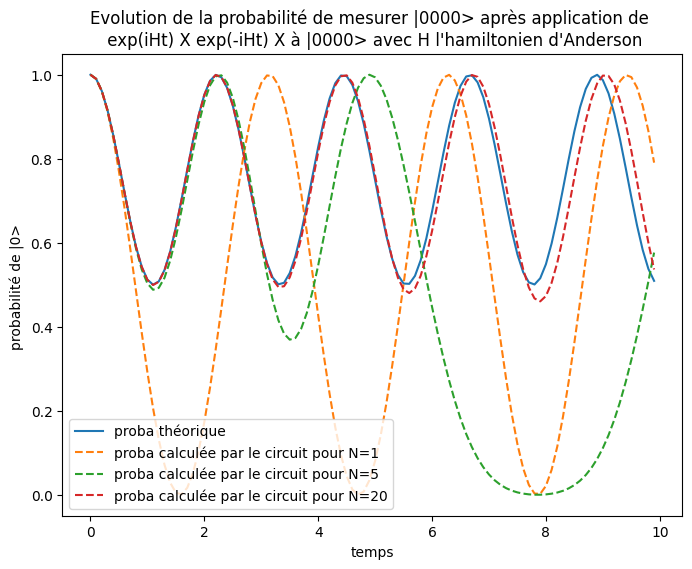

In [403]:
T = np.arange(0, 10, 0.1)
resultatTheoriqueA = [calculTheoriqueAnderson(t, 0) for t in T]
plt.figure(figsize=(8,6))
plt.plot(T, resultatTheoriqueA, label = 'proba théorique')

for N_steps in [1, 5, 20] :
    resultatCirc = [circuitGreenProba(0, "+", 0, "+", AndersonHamiltonian, t, N=N_steps, XYarray=["X","X"])["0000"] for t in T]
    plt.plot(T, resultatCirc, label = f'proba calculée par le circuit pour N={N_steps}', linestyle='--')

plt.xlabel('temps')
plt.ylabel('probabilité de |0> ')
plt.title("Evolution de la probabilité de mesurer |0000> après application de \n exp(iHt) X exp(-iHt) X à |0000> avec H l'hamiltonien d'Anderson")
plt.legend()
plt.show()

In [404]:
print(circuitGreenProba(0, "+", 0, "+", AndersonHamiltonian, 9.9, N=N_steps, XYarray=["X","X"]))

{'0000': 0.5364217758448608, '1010': 0.4635782241550905}


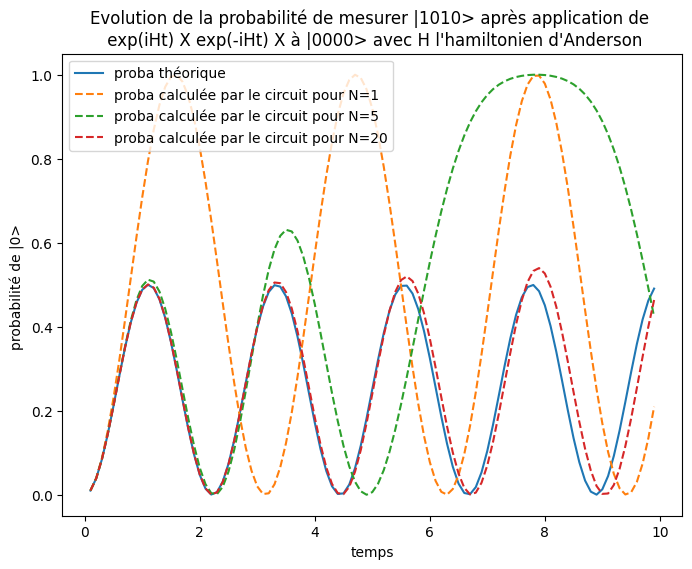

In [405]:
T = np.arange(0.1, 10, 0.1)
resultatTheoriqueA = [calculTheoriqueAnderson(t, 10) for t in T]
plt.figure(figsize=(8,6))
plt.plot(T, resultatTheoriqueA, label = 'proba théorique')

for N_steps in [1, 5, 20] :
    
    resultatCirc = [circuitGreenProba(0, "+", 0, "+", AndersonHamiltonian, t, N=N_steps, XYarray=["X","X"])['1010'] for t in T]
    plt.plot(T, resultatCirc, label = f'proba calculée par le circuit pour N={N_steps}', linestyle='--')

plt.xlabel('temps')
plt.ylabel('probabilité de |0> ')
plt.title("Evolution de la probabilité de mesurer |1010> après application de \n exp(iHt) X exp(-iHt) X à |0000> avec H l'hamiltonien d'Anderson")
plt.legend()
plt.show()

On peut essayer de calculer la fonction de Green autrement en utilisant le fait qu'elle s'applique à l'état fondamental

Il reste à calculer la moyenne $\exp{(iHt)} c_{j,\sigma} \exp{(-iHt)} c_{i, \sigma'}^{\dagger} \ket{\psi_{0}}$ and $\ket{\psi_{0}}$ avec un test de Hadamard. Pour cela on construit une porte controle U où U est la fonction entre le bra et le ket dans la fonction de Green :

In [406]:
Correlator = circuitGreen(0, "+", 0, "+", H_test2, 10 , N=2, XYarray=["X","X"])

qpu = get_default_qpu()

routineT = QRoutine()
routineT.apply(H, 0)
routineT.apply(S.dag(), 0)
routineT.apply(Correlator.ctrl(), [range(2)])
routineT.apply(H, 0)
mesureZ = Observable(2, pauli_terms=[Term(1, 'Z', [0])])
jobT = routineT.to_job(observable = mesureZ)
resultT = qpu.submit(jobT)

print(resultT.value)
routineT.display()

-0.5431633853307865


In [407]:
def realHTest(psi_0, i, sigma_i, j, sigma_j, h, t, N, XYarray) :
    n_qubits = h.nbqbits
    routineH = QRoutine()
    routineH.apply(psi_0, [range(1, psi_0.arity + 1)])
    routineH.apply(H, 0)
    correlator = circuitGreen(i, sigma_i, j, sigma_j, h, t, N, XYarray)
    routineH.apply(correlator.ctrl(), [range(n_qubits + 1)])
    routineH.apply(H, 0)

    return routineH

def imHTest(psi_0, i, sigma_i, j, sigma_j, h, t, N, XYarray) :
    n_qubits = h.nbqbits
    routineH = QRoutine()

    routineH.apply(H, 0)
    routineH.apply(S.dag(), 0)

    routineH.apply(psi_0, [range(1,psi_0.arity + 1)])

    correlator = circuitGreen(i, sigma_i, j, sigma_j, h, t, N, XYarray)
    
    routineH.apply(correlator.ctrl(), [range(n_qubits + 1)])
    routineH.apply(H, 0)
    return routineH

imHTest(psi0, 0, "+", 0, "+", AndersonHamiltonian, 1, 1, ["X","X"]).display()

In [408]:
def circuitGreenTest(psi_0, i, sigma_i, j, sigma_j, h, t, N, XYarray) :
    amplitudes = {}
    rout = QRoutine()
    rout.apply(psi_0, [range(psi_0.arity)])
    rout.apply(circuitGreen(i, sigma_i, j, sigma_j, h, t, N, XYarray), [range(h.nbqbits)])
    qpu = get_default_qpu()
    job = rout.to_job()
    result = qpu.submit(job)

    for sample in result :
        amplitudes[sample.state] = sample.amplitude
    
    return amplitudes
for XYarray in [['X','X'],['X','Y'],['Y','X'],['Y','Y']] :
    print(circuitGreenTest(psi0, 1, "+", 0, "+", AndersonHamiltonian, 1, 1, XYarray))
print(psi0_dict)

{|0010>: (0.10415097425149744-0.7522946419389448j), |1000>: (0.22879642698587951-0.6089807396551261j)}
{|0010>: (0.16746860174566408+0.2653016491329262j), |1000>: (-0.5445027261639598+0.7778727939687244j)}
{|0010>: (0.16746860174566422+0.26530164913292603j), |1000>: (-0.5445027261639594+0.777872793968724j)}
{|0010>: (0.10415097425149761-0.752294641938945j), |1000>: (0.22879642698587968-0.6089807396551264j)}
{'0010': (0.2893700445994568+0.16139568737427792j), '1000': (-0.8240649758948396-0.45949246445281794j)}


In [409]:
def testG_t(psi_0, i : int, sigma_i : str, j : int, sigma_j : str, h, t : float, N : int) :
    arrays = [['X','X'],['X','Y'],['Y','X'],['Y','Y']]
    qpu = get_default_qpu()
    GreenFunc = 0
    
    job = psi_0.to_job()
    resultat0 = qpu.submit(job)
    
    for XYarray in arrays :
        for sample in resultat0 :  
        
            circ = circuitGreenTest(psi_0, i, sigma_i , j , sigma_j , h, t, N, XYarray) #dictionnaire d'amplitudes
            for etat in circ :

                if sample.state.bitstring == etat.bitstring :
                    GreenFunc += (1/4) * ((np.real(sample.amplitude)*np.real(circ[etat]) + np.imag(sample.amplitude)*np.imag(circ[etat])) +\
                                          1j * (np.real(sample.amplitude)*np.imag(circ[etat]) + np.imag(-sample.amplitude)*np.real(circ[etat])))
                
    return -1j * GreenFunc



In [ ]:
def G_t(psi_0, i : int, sigma_i : str, j : int, sigma_j : str, h, t : float, N : int) :
    
    GreenFunction = 0
    n_qubits = h.nbqbits    
    arrays = [['X','X'],['X','Y'],['Y','X'],['Y','Y']]
    for XYarray in arrays :
        obs = Observable(n_qubits + 1, pauli_terms=[Term(1, "Z", [0])])

        qpu = get_default_qpu()
        
        job_ReHtest = realHTest(psi_0, i, sigma_i, j, sigma_j, h, t, N, XYarray).to_job(observable=obs)
        result_ReHtest = qpu.submit(job_ReHtest)

        job_ImHtest = imHTest(psi_0, i, sigma_i, j, sigma_j, h, t, N, XYarray).to_job(observable=obs)
        result_ImHtest = qpu.submit(job_ImHtest)
        
        GreenFunction += 1/4 * (result_ReHtest.value + 1j * result_ImHtest.value)

    return -1j * GreenFunction


print(G_t(psi0, 0, "+", 0, "+", AndersonHamiltonian, 1, 1))


(-0.213147540396379-0.03208003279323496j)


In [411]:
print("Test", testG_t(psi0, 0, "+", 0, "+" , AndersonHamiltonian, 1 , 1))
print("Fonction calculée avec circuit :", G_t(psi0, 0, "+", 0, "+", AndersonHamiltonian, 1, 1))
print()
print("Test",testG_t(psi0, 0, "+", 0, "+" , AndersonHamiltonian, 5 , 1))
print("Fonction calculée avec circuit :", G_t(psi0, 0, "+", 0, "+", AndersonHamiltonian, 5, 1))
print()

print("Test",testG_t(psi0, 0, "+", 0, "+" , AndersonHamiltonian, 11 , 1))
print("Fonction calculée avec circuit :", G_t(psi0, 0, "+", 0, "+", AndersonHamiltonian, 11, 1))
print()

print("Test",testG_t(psi0, 1, "+", 0, "+" , AndersonHamiltonian, 1 , 1))
print("Fonction calculée avec circuit :", G_t(psi0, 1, "+", 0, "+", AndersonHamiltonian, 1, 1))
print()
print("Test",testG_t(psi0, 1, "+", 0, "+" , AndersonHamiltonian, 5 , 1))
print("Fonction calculée avec circuit :", G_t(psi0, 1, "+", 0, "+", AndersonHamiltonian, 5, 1))



Test (-0.21314754039637887-0.03208003279323504j)
Fonction calculée avec circuit : (-0.213147540396379-0.03208003279323496j)

Test (0.26991643960836714-0.008798001516639658j)
Fonction calculée avec circuit : (0.26991643960836736-0.008798001516639543j)

Test (0.31213089508706726+3.502762015845928e-05j)
Fonction calculée avec circuit : (0.3121308950870675+3.5027620158445405e-05j)

Test (-0.23450105216982606-0.09127893877948963j)
Fonction calculée avec circuit : (-0.23450105216982653-0.09127893877948959j)

Test (0.19031303266831157-0.02514460199630038j)
Fonction calculée avec circuit : (0.19031303266831165-0.02514460199630035j)


<h2>Pour calculer la fonction spectrale, il faut calculer la fonction de Green retardée :</h2> 


$\langle \{ c_\alpha(t), c^\dagger_{\alpha'}(t') \} \rangle$, donc il faut faire la même démarche mais cette fois-ci avec $c^\dagger_{j, \sigma} e^{i H t} c_{i, \sigma'} e^{-i H t}$

In [412]:
def circuitGreen_CDagC(i, sigma_i, j, sigma_j, h, t, N, XYarray) :
    n = h.nbqbits
    rout = QRoutine()
    routX_c, qubitsX, routY_c, qubitsY = cMapping(i, sigma_i)
    routX_cdag, qubitsX_dag, routY_cdag, qubitsY_dag = cDagMapping(j, sigma_j)
    
    rout.apply(make_trotterisation_routine(h, n_trotter_steps=N, final_time=t), [range(n)]) #Trotterization avec -H
    if XYarray[0] == "X" :
        rout.apply(routX_c, qubitsX)
    else :
        rout.apply(routY_c, qubitsY)
    
    rout.apply(make_trotterisation_routine((-1)*h, n_trotter_steps=N, final_time=t), [range(n)]) #Trotterization avec H

    if XYarray[1] == "X" : #optimisation future circuitX_cdag = circuitX_c
        rout.apply(routX_cdag, qubitsX_dag)
    else :
        rout.apply(routY_cdag, qubitsY_dag)

    return rout

circuitGreen_CDagC(0, "+", 0, "+", H_test3(np.pi/3), 1, 1, ["X","Y"]).display()
circuitGreen(0, "+", 0, "+", H_test3(np.pi/3), 1, 1, ["X","Y"]).display()


In [413]:
def realHTest_CDagC(psi_0, i, sigma_i, j, sigma_j, h, t, N, XYarray) :
    n_qubits = h.nbqbits
    routineH = QRoutine()
    routineH.apply(psi_0, [range(1, psi_0.arity + 1)])
    routineH.apply(H, 0)
    correlator = circuitGreen_CDagC(i, sigma_i, j, sigma_j, h, t, N, XYarray)
    routineH.apply(correlator.ctrl(), [range(n_qubits + 1)])
    routineH.apply(H, 0)

    return routineH

def imHTest_CDagC(psi_0, i, sigma_i, j, sigma_j, h, t, N, XYarray) :
    n_qubits = h.nbqbits
    routineH = QRoutine()

    routineH.apply(H, 0)
    routineH.apply(S.dag(), 0)

    routineH.apply(psi_0, [range(1,psi_0.arity + 1)])

    correlator = circuitGreen_CDagC(i, sigma_i, j, sigma_j, h, t, N, XYarray)
    
    routineH.apply(correlator.ctrl(), [range(n_qubits + 1)])
    routineH.apply(H, 0)
    return routineH

qrout1 = QRoutine()
qrout1.apply(I, 0)
realHTest_CDagC(qrout1, 0, "+", 0, "+", H_test3(np.pi/3), 1, 1, ["X","Y"]).display()
imHTest_CDagC(qrout1, 0, "+", 0, "+", H_test3(np.pi/3), 1, 1, ["X","Y"]).display()

In [414]:
def G_t_CDagC(psi_0, i : int, sigma_i : str, j : int, sigma_j : str, h, t : float, N : int) :
    GreenFunction = 0
    n_qubits = h.nbqbits    
    arrays = [['X','X'],['X','Y'],['Y','X'], ['Y','Y']]
    for XYarray in arrays :
        obs = Observable(n_qubits + 1, pauli_terms=[Term(1, "Z", [0])])

        qpu = get_default_qpu()
        
        job_ReHtest = realHTest_CDagC(psi_0, i, sigma_i, j, sigma_j, h, t, N, XYarray).to_job(observable=obs)
        result_ReHtest = qpu.submit(job_ReHtest)
        
        job_ImHtest = imHTest_CDagC(psi_0, i, sigma_i, j, sigma_j, h, t, N, XYarray).to_job(observable=obs)
        result_ImHtest = qpu.submit(job_ImHtest)
        GreenFunction += 1/4 * (result_ReHtest.value + 1j * result_ImHtest.value)

    return -1j * GreenFunction

In [415]:
def circuitGreenTest_CDagC(psi_0, i, sigma_i, j, sigma_j, h, t, N, XYarray) :
    amplitudes = {}
    rout = QRoutine()
    rout.apply(psi_0, [range(psi_0.arity)])
    rout.apply(circuitGreen_CDagC(i, sigma_i, j, sigma_j, h, t, N, XYarray), [range(h.nbqbits)])
    qpu = get_default_qpu()
    job = rout.to_job()
    result = qpu.submit(job)

    for sample in result :
        amplitudes[sample.state] = sample.amplitude
    
    return amplitudes
for XYarray in [['X','X'],['X','Y'],['Y','X'],['Y','Y']] :
    print(circuitGreenTest_CDagC(psi0, 1, "+", 0, "+", AndersonHamiltonian, 1, 1, XYarray))
print(psi0_dict)

{|0010>: (-0.10415097425149744+0.7522946419389451j), |1000>: (-0.22879642698587951+0.6089807396551262j)}
{|0010>: (0.10415097425149744-0.7522946419389451j), |1000>: (-0.22879642698587951+0.6089807396551262j)}
{|0010>: (0.10415097425149739-0.7522946419389452j), |1000>: (-0.2287964269858796+0.6089807396551263j)}
{|0010>: (-0.10415097425149739+0.7522946419389452j), |1000>: (-0.2287964269858796+0.6089807396551263j)}
{'0010': (0.2893700445994568+0.16139568737427792j), '1000': (-0.8240649758948396-0.45949246445281794j)}


In [416]:
def testG_t_CDagC(psi_0, i : int, sigma_i : str, j : int, sigma_j : str, h, t : float, N : int) :
    arrays = [['X','X'],['X','Y'],['Y','X'],['Y','Y']]
    qpu = get_default_qpu()
    GreenFunc = 0
    
    job = psi_0.to_job()
    resultat0 = qpu.submit(job)
    
    for XYarray in arrays :
        for sample in resultat0 :  
        
            circ = circuitGreenTest_CDagC(psi_0, i, sigma_i , j , sigma_j , h, t, N, XYarray) #dictionnaire d'amplitudes
            for etat in circ :

                if sample.state.bitstring == etat.bitstring :
                    GreenFunc += (1/4) * ((np.real(sample.amplitude)*np.real(circ[etat]) + np.imag(sample.amplitude)*np.imag(circ[etat])) +\
                                          1j * (np.real(sample.amplitude)*np.imag(circ[etat]) + np.imag(-sample.amplitude)*np.real(circ[etat])))
                
    return -1j * GreenFunc

In [417]:
print("Test", testG_t_CDagC(psi0, 0, "+", 0, "+" , AndersonHamiltonian, 1 , 1))
print("Fonction calculée avec circuit :", G_t_CDagC(psi0, 0, "+", 0, "+", AndersonHamiltonian, 1, 1))
print()
print("Test",testG_t_CDagC(psi0, 0, "+", 0, "+" , AndersonHamiltonian, 5 , 1))
print("Fonction calculée avec circuit :", G_t_CDagC(psi0, 0, "+", 0, "+", AndersonHamiltonian, 5, 1))
print()

print("Test",testG_t_CDagC(psi0, 0, "+", 0, "+" , AndersonHamiltonian, 11 , 1))
print("Fonction calculée avec circuit :", G_t_CDagC(psi0, 0, "+", 0, "+", AndersonHamiltonian, 11, 1))
print()

print("Test",testG_t_CDagC(psi0, 1, "+", 0, "+" , AndersonHamiltonian, 1 , 1))
print("Fonction calculée avec circuit :", G_t_CDagC(psi0, 1, "+", 0, "+", AndersonHamiltonian, 1, 1))
print()
print("Test",testG_t_CDagC(psi0, 1, "+", 0, "+" , AndersonHamiltonian, 5 , 1))
print("Fonction calculée avec circuit :", G_t_CDagC(psi0, 1, "+", 0, "+", AndersonHamiltonian, 5, 1))



Test (0.6677962538092164-0.25984654893319176j)
Fonction calculée avec circuit : (0.6677962538092166-0.2598465489331916j)

Test (-0.5419269950530502-0.07166623394513347j)
Fonction calculée avec circuit : (-0.5419269950530502-0.07166623394513333j)

Test (-0.3165565497322691-5.461442283977158e-05j)
Fonction calculée avec circuit : (-0.3165565497322695-5.461442283960505e-05j)

Test (-0.6069699326380643+0.09127893877948962j)
Fonction calculée avec circuit : (-0.6069699326380633+0.09127893877948953j)

Test (0.7686112419948199+0.02514460199630031j)
Fonction calculée avec circuit : (0.7686112419948198+0.025144601996300642j)


In [418]:
def Gr_t(psi_0, i : int, sigma_i : str, j : int, sigma_j : str, h, t : float, N : int) :
    return G_t(psi_0, i, sigma_i, j, sigma_j, h, t, N) + G_t_CDagC(psi_0, i, sigma_i, j, sigma_j, h, t, N)

<h2>On passe à la construction de la fonction spectrale et donc des transformées de Fourier qu'il faut effectuer pour y parvenir</h2>

In [422]:
def Gr_w(psi_0, i : int, sigma_i : str, j : int, sigma_j : str, h, timeArray : np.ndarray, N : int) -> np.ndarray :
    listGr_t = []
    dt = timeArray[1] - timeArray[0]
    for time in timeArray :
        listGr_t.append(Gr_t(psi_0, i, sigma_i, j, sigma_j, h, time, N))
    frequencies = np.fft.fftfreq(len(timeArray), dt) * 2 * np.pi
    return np.fft.ifft(listGr_t) * dt, np.fft.fftshift(frequencies)

In [423]:
#renvoie un array avec la fonction spectrale et un array de fréquences
def spectralFunction(psi_0, i : int, sigma_i : str, j : int, sigma_j : str, h, timeArray : np.ndarray, N : int) : 
    Green_w, pulsations = Gr_w(psi_0, i, sigma_i, j, sigma_j, h, timeArray, N)
    spectre = (-1/np.pi) * np.imag(np.fft.fftshift(Green_w))

    return spectre, pulsations

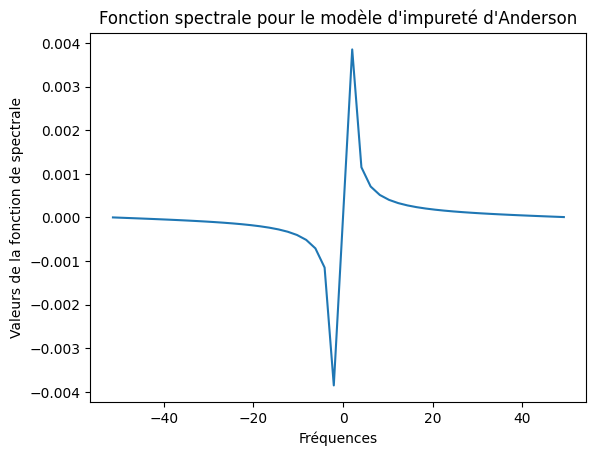

In [429]:
timeList = np.linspace(0, 3, 50)

values, freq = spectralFunction(psi0, 0, "+", 1, "+", AndersonHamiltonian, timeList, 15)
plt.plot(freq, values, label="Fonction spectrale")
plt.xlabel("Fréquences")
plt.ylabel("Valeurs de la fonction de spectrale")
plt.title("Fonction spectrale pour le modèle d'impureté d'Anderson")

plt.show()


In [ ]:
timeList = np.linspace(0, 3, 80)

values, freq = spectralFunction(psi0, 0, "+", 0, "+", AndersonHamiltonian, timeList, 30)
plt.plot(freq, values, label="Fonction spectrale")
plt.xlabel("Fréquences")
plt.ylabel("Valeurs de la fonction de spectrale")
plt.title("Fonction spectrale pour le modèle d'impureté d'Anderson")

plt.show()

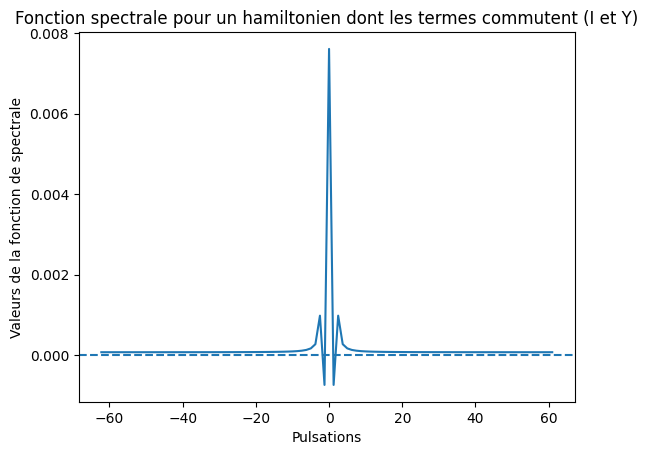

In [427]:
timeList = np.linspace(0, 5, 100)
qrout_ini = QRoutine()
qrout_ini.apply(Y, 0)
qrout_ini.apply(H, 0)
values, freq = spectralFunction(qrout_ini, 0, "+", 0, "+", H_test3(np.pi/2), timeList, 1)
plt.plot(freq, values, label="Fonction spectrale")
plt.xlabel("Pulsations")
plt.ylabel("Valeurs de la fonction de spectrale")
plt.axhline(y = 0, linestyle = '--')
plt.title("Fonction spectrale pour un hamiltonien dont les termes commutent (I et Y)")

plt.show()


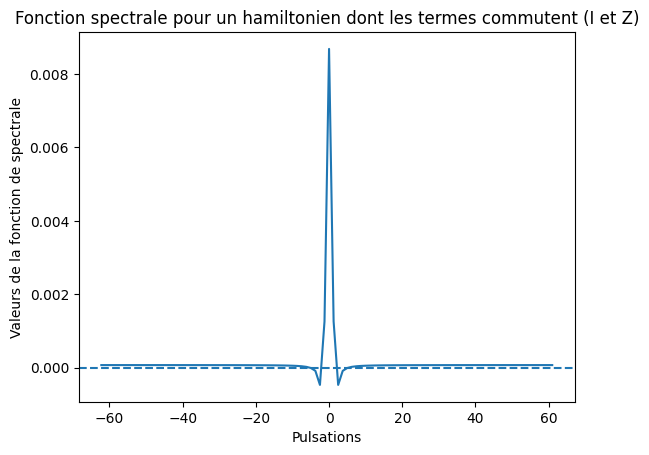

In [428]:
values, freq = spectralFunction(qrout_ini, 0, "+", 0, "+", H_test4(np.pi/3), timeList, 1)
plt.plot(freq, values, label="Fonction spectrale")
plt.xlabel("Pulsations")
plt.ylabel("Valeurs de la fonction de spectrale")
plt.axhline(y = 0, linestyle = '--')
plt.title("Fonction spectrale pour un hamiltonien dont les termes commutent (I et Z)")

plt.show()


<h1>!! A FAIRE !!</h1>
<h2> Ajouter un module pour initialiser à psi0 le circuit calculant la fonction de Green</h2>
<h2>Régler la fonction de trotterization qui ne marche pas lorsque l'hamiltonien n'agit pas sur tous les qubits</h2>

<h2>TESTS</h2>


In [120]:
def G_Lehman(valeurs_prop: np.ndarray[float], vecteurs_prop: np.ndarray[float], beta: float, n_site_bain, omegas):
    n_site = n_site_bain + 1
    dim, nb_vp = np.shape(vecteurs_prop)
    N = len(omegas)
    valeurs_prop = valeurs_prop - valeurs_prop[0]
    resu = np.zeros(N,dtype = 'complex_')
    Z = np.sum(np.exp(-beta*(valeurs_prop)))
    S = 0
    somme_coef = 0
    for i in range(nb_vp):
        for j in range(nb_vp):
            prod_scal = 0
            for k in range(2**(2*n_site - 1)):
                sig_k = 2*k + 1
                prod_scal += vecteurs_prop[sig_k, j].conj() * vecteurs_prop[2*k, i]
            prod_scal = np.real(prod_scal)**2 + np.imag(prod_scal)** 2
            somme_coef += (np.exp(-beta*valeurs_prop[i]) + np.exp(-beta*valeurs_prop[j])) * prod_scal
            for n in range(N):
                resu[n] += ((np.exp(-beta*valeurs_prop[i]) + np.exp(-beta*valeurs_prop[j])) * prod_scal ) / (
                        valeurs_prop[j] - valeurs_prop[i] - 1j * omegas[n])
    return -resu/Z
